Anh Tu Duong Nguyen (anguyea, 115931)

Anh-Nhat Nguyen (anhnnguy, 2034311)

In [1]:
# make sure you installed the mnist1d package

%load_ext autoreload
%autoreload 2
import torch
from a02_functions import SimpleCNN, SimpleMLP, train_model
from a02_helper import (
    plot_templates,
    get_raw_data,
    count_model_params,
    shuffle_pixels,
    plot_example,
    nextplot,
)

# Task 2: MNIST-1D
### Dataset

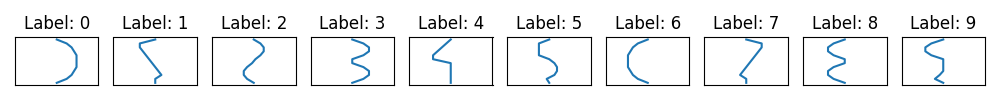

In [2]:
# Those are the templates that the examples in the dataset are based on.
nextplot()
plot_templates()

In [3]:
data = get_raw_data()

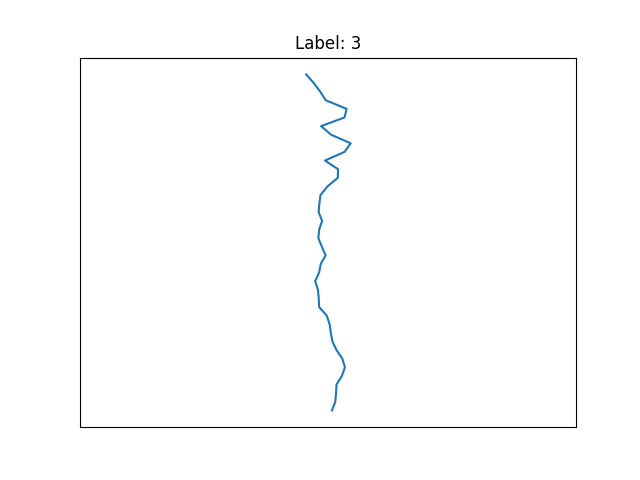

In [4]:
idx = 8
x, y, t = data["x"][idx], data["y"][idx], data["t"]
nextplot()
plot_example(x, y, t)

### Model

Verify your model's implementation by running the following test cases.

In [5]:
torch.manual_seed(0)
cnn = SimpleCNN()
x_unbatched = torch.ones(40)
x_batched = x_unbatched.view(1, -1)
with torch.no_grad():  # these should give no error
    y_batched = cnn(x_batched)
    y_unbatched = cnn(x_unbatched)

x_batched, x_unbatched  # these are the inputs being used

(tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
          1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
          1., 1., 1., 1.]]),
 tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1., 1., 1.]))

Initialize your model and verify the total number of parameters computed by
hand.

In [6]:
torch.manual_seed(0)
cnn = SimpleCNN()
print(cnn)
print(f"No. of parameters: {count_model_params(cnn)}")

SimpleCNN(
  (conv1): Conv1d(1, 25, kernel_size=(3,), stride=(2,), padding=(1,))
  (conv2): Conv1d(25, 25, kernel_size=(3,), stride=(2,), padding=(1,))
  (conv3): Conv1d(25, 25, kernel_size=(3,), stride=(2,), padding=(1,))
  (conv4): Conv1d(25, 25, kernel_size=(3,), stride=(2,), padding=(1,))
  (lin1): Linear(in_features=25, out_features=10, bias=True)
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
)
No. of parameters: 6060


### Training

Train your model.

In [7]:
results = train_model(data, cnn)

epoch 0, dt 1.21s, train_loss 1.515e+00, val_loss 1.446e+00, train_acc 40.7, val_acc 40.8
epoch 10, dt 1.78s, train_loss 4.498e-01, val_loss 7.026e-01, train_acc 80.0, val_acc 70.4
epoch 20, dt 1.71s, train_loss 2.554e-01, val_loss 4.688e-01, train_acc 93.4, val_acc 85.8
epoch 30, dt 1.82s, train_loss 5.536e-02, val_loss 7.090e-01, train_acc 95.5, val_acc 84.8
epoch 40, dt 1.71s, train_loss 4.144e-02, val_loss 6.942e-01, train_acc 98.2, val_acc 87.9
epoch 50, dt 1.79s, train_loss 3.477e-02, val_loss 6.134e-01, train_acc 99.3, val_acc 89.2
epoch 60, dt 1.78s, train_loss 8.532e-02, val_loss 7.925e-01, train_acc 98.0, val_acc 88.5
epoch 70, dt 1.58s, train_loss 4.603e-03, val_loss 6.392e-01, train_acc 100.0, val_acc 88.8
epoch 80, dt 1.73s, train_loss 4.246e-04, val_loss 6.745e-01, train_acc 100.0, val_acc 90.0
epoch 90, dt 1.78s, train_loss 5.494e-04, val_loss 7.000e-01, train_acc 100.0, val_acc 90.5
Final result: train_loss 3.064e-04, val_loss 7.000e-01, test_loss 5.889e-01, train_acc 1

### Simple Feedforward Neural Network

Compare the results of the CNN and FNN models (after your conjecture!).

In [8]:
torch.manual_seed(0)
fnn = SimpleMLP()
print(f"No. of parameters: {count_model_params(fnn)}")

No. of parameters: 78858


In [9]:
results = train_model(data, fnn)

epoch 0, dt 0.24s, train_loss 1.584e+00, val_loss 1.562e+00, train_acc 46.2, val_acc 39.9
epoch 10, dt 1.15s, train_loss 4.915e-01, val_loss 1.469e+00, train_acc 87.4, val_acc 57.5
epoch 20, dt 1.04s, train_loss 3.380e-01, val_loss 1.991e+00, train_acc 94.7, val_acc 62.4
epoch 30, dt 1.04s, train_loss 1.785e-01, val_loss 2.736e+00, train_acc 96.1, val_acc 60.5
epoch 40, dt 1.06s, train_loss 1.676e-02, val_loss 3.186e+00, train_acc 99.2, val_acc 61.2
epoch 50, dt 1.04s, train_loss 5.400e-01, val_loss 3.732e+00, train_acc 93.9, val_acc 58.0
epoch 60, dt 1.02s, train_loss 7.052e-04, val_loss 3.611e+00, train_acc 100.0, val_acc 65.5
epoch 70, dt 1.20s, train_loss 2.800e-04, val_loss 3.613e+00, train_acc 100.0, val_acc 65.6
epoch 80, dt 1.27s, train_loss 1.224e-04, val_loss 3.638e+00, train_acc 100.0, val_acc 65.4
epoch 90, dt 1.42s, train_loss 5.801e-05, val_loss 3.665e+00, train_acc 100.0, val_acc 65.1
Final result: train_loss 8.169e-05, val_loss 3.665e+00, test_loss 3.544e+00, train_acc 

### Shuffled Dataset

Shuffle the dataset along the spatial dimension.

In [10]:
shuffled_dataset = shuffle_pixels(data)

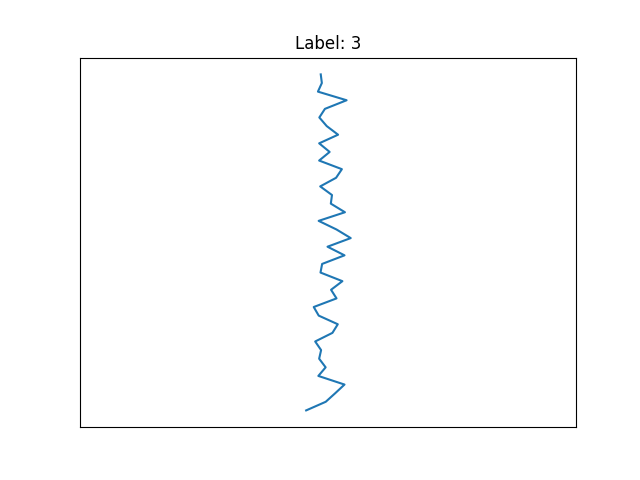

In [11]:
idx = 8
x, y, t = shuffled_dataset["x"][idx], shuffled_dataset["y"][idx], shuffled_dataset["t"]
nextplot()
plot_example(x, y, t)

In [12]:
torch.manual_seed(0)
cnn = SimpleCNN()
results = train_model(shuffled_dataset, cnn)

epoch 0, dt 0.22s, train_loss 1.723e+00, val_loss 1.673e+00, train_acc 32.4, val_acc 32.5
epoch 10, dt 1.87s, train_loss 8.741e-01, val_loss 1.245e+00, train_acc 60.6, val_acc 52.2
epoch 20, dt 1.90s, train_loss 7.436e-01, val_loss 1.226e+00, train_acc 70.7, val_acc 56.4
epoch 30, dt 1.89s, train_loss 8.191e-01, val_loss 1.391e+00, train_acc 78.8, val_acc 58.9
epoch 40, dt 2.14s, train_loss 4.207e-01, val_loss 1.457e+00, train_acc 82.9, val_acc 59.5
epoch 50, dt 1.69s, train_loss 4.025e-01, val_loss 1.854e+00, train_acc 84.3, val_acc 58.4
epoch 60, dt 1.74s, train_loss 3.997e-01, val_loss 2.066e+00, train_acc 82.8, val_acc 56.5
epoch 70, dt 1.94s, train_loss 3.749e-01, val_loss 2.280e+00, train_acc 86.1, val_acc 57.1
epoch 80, dt 1.31s, train_loss 2.175e-01, val_loss 2.619e+00, train_acc 90.4, val_acc 59.0
epoch 90, dt 1.20s, train_loss 2.061e-01, val_loss 2.862e+00, train_acc 90.7, val_acc 57.2
Final result: train_loss 2.739e-01, val_loss 2.862e+00, test_loss 2.863e+00, train_acc 90.7

In [13]:
torch.manual_seed(0)
fnn = SimpleMLP()
results = train_model(shuffled_dataset, fnn)

epoch 0, dt 0.11s, train_loss 1.593e+00, val_loss 1.561e+00, train_acc 46.6, val_acc 40.5
epoch 10, dt 0.68s, train_loss 4.558e-01, val_loss 1.408e+00, train_acc 84.7, val_acc 59.9
epoch 20, dt 0.67s, train_loss 1.653e-01, val_loss 1.928e+00, train_acc 95.2, val_acc 61.1
epoch 30, dt 0.64s, train_loss 7.692e-02, val_loss 2.452e+00, train_acc 97.5, val_acc 60.6
epoch 40, dt 0.72s, train_loss 2.055e-02, val_loss 2.858e+00, train_acc 99.3, val_acc 61.6
epoch 50, dt 0.67s, train_loss 1.022e-03, val_loss 2.686e+00, train_acc 100.0, val_acc 63.5
epoch 60, dt 0.63s, train_loss 6.603e-04, val_loss 2.730e+00, train_acc 100.0, val_acc 63.9
epoch 70, dt 0.65s, train_loss 3.851e-04, val_loss 2.775e+00, train_acc 100.0, val_acc 64.1
epoch 80, dt 0.64s, train_loss 2.969e-04, val_loss 2.821e+00, train_acc 100.0, val_acc 64.5
epoch 90, dt 0.63s, train_loss 1.459e-04, val_loss 2.865e+00, train_acc 100.0, val_acc 64.6
Final result: train_loss 2.155e-04, val_loss 2.865e+00, test_loss 3.092e+00, train_acc